In [68]:
import re
import subprocess
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import spacy
import textstat
from nltk.corpus import stopwords
from nltk.util import ngrams
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [16]:
PROJECT_ROOT = Path().resolve().parent
print(PROJECT_ROOT)

PDF_PATH = PROJECT_ROOT / "data/raw/documentation/Mental Health of Older Persons/001_ECE_PB29_EN.pdf"
print(PDF_PATH)

OUTPUT_DIR = PROJECT_ROOT / "data/research/Mental Health of Older Persons/output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(OUTPUT_DIR)

/Users/z.yang/playground/techdoc-rag
/Users/z.yang/playground/techdoc-rag/data/raw/documentation/Mental Health of Older Persons/001_ECE_PB29_EN.pdf
/Users/z.yang/playground/techdoc-rag/data/research/Mental Health of Older Persons/output


In [17]:
# Convert PDF → Markdown using Marker
cmd = [
    "marker_single",
    str(PDF_PATH),
    "--output_dir",
    str(OUTPUT_DIR)
]

result = subprocess.run(cmd, capture_output=True, text=True)

print("===== STDOUT =====")
print(result.stdout)
print("\n===== STDERR =====")
print(result.stderr)

===== STDOUT =====


===== STDERR =====
2026-05-30 00:05:52,769 [WARNING] surya: `TableRecEncoderDecoderModel` is not compatible with mps backend. Defaulting to cpu instead

Recognizing Layout: 100%|██████████| 24/24 [03:05<00:00,  7.74s/it]

Running OCR Error Detection: 100%|██████████| 6/6 [00:01<00:00,  5.06it/s]

Detecting bboxes: 100%|██████████| 1/1 [00:01<00:00,  1.77s/it]

Recognizing Text: 100%|██████████| 6/6 [00:08<00:00,  1.38s/it]

Recognizing tables: 100%|██████████| 1/1 [00:04<00:00,  4.74s/it]

Detecting bboxes: 100%|██████████| 1/1 [00:01<00:00,  1.95s/it]

Recognizing Text: 100%|██████████| 86/86 [02:51<00:00,  1.99s/it]
2026-05-30 00:12:16,636 [INFO] marker: Saved markdown to /Users/z.yang/playground/techdoc-rag/data/research/Mental Health of Older Persons/output/001_ECE_PB29_EN
2026-05-30 00:12:16,636 [INFO] marker: Total time: 382.85045409202576



In [19]:
# Load Markdown
md_file = next(OUTPUT_DIR.glob("**/*.md"))

markdown_text = md_file.read_text(
    encoding="utf-8"
)

print(markdown_text[:2000])

![](_page_0_Picture_2.jpeg)

<span id="page-0-0"></span>![](_page_0_Picture_3.jpeg)

![](_page_0_Picture_4.jpeg)

# Policy Brief on Ageing

# Mental Health of Older Persons

#### Contents

| Mental health of older persons:  |    |
|----------------------------------|----|
| a human right and priority for   |    |
| sustainable development          | 2  |
| Determinants of mental health    |    |
| in later life                    | 2  |
| Prevalence of mental health      |    |
| conditions among older persons   |    |
| in the UNECE region              | 5  |
| Policy strategies to improve the |    |
| mental health of older persons   | 9  |
| Conclusions                      | 18 |
| Checklist                        | 20 |
| References                       | 22 |

# Suggested strategies

- Address specific needs of older persons in mental health policies
- Eliminate stigma and improve mental health literacy
- Combat ageism
- Invest in prevention and early detection
- Tackle psychoso

In [23]:
# Basic Document Statistics
tokens = re.findall(
    r"[A-Za-z]+",
    markdown_text.lower()
)

stats = {
    "characters": len(markdown_text),
    "words": len(tokens),
    "vocabulary_size": len(set(tokens)),
    "lexical_diversity": len(set(tokens)) / len(tokens),
}

pd.Series(stats)

characters           114276.000000
words                 14916.000000
vocabulary_size        2196.000000
lexical_diversity         0.147224
dtype: float64

In [24]:
# Heading Structure Analysis
headings = re.findall(
    r"^(#+)\s+(.*)$",
    markdown_text,
    flags=re.MULTILINE,
)

heading_df = pd.DataFrame(
    [
        {
            "level": len(level),
            "title": title.strip(),
        }
        for level, title in headings
    ]
)

heading_df.head(20)

,level,title
0,1,Policy Brief on Ageing
1,1,Mental Health of Older Persons
2,4,Contents
3,1,Suggested strategies
4,1,Policy challenge
5,1,What this brief is about
6,1,"<span id=""page-1-0""></span>Mental health of ol..."
7,1,Determinants of mental health in later life
8,4,Individual determinants
9,4,Table 1 Definitions


In [28]:
# Count headings by level
heading_df["level"].value_counts().sort_index()

level
1    12
2    14
4    54
Name: count, dtype: int64

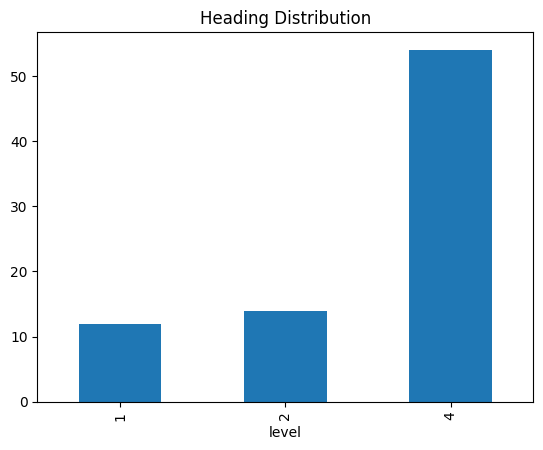

In [30]:
# Visualize
heading_df["level"].value_counts() \
    .sort_index() \
    .plot(kind="bar")

plt.title("Heading Distribution")
plt.show()

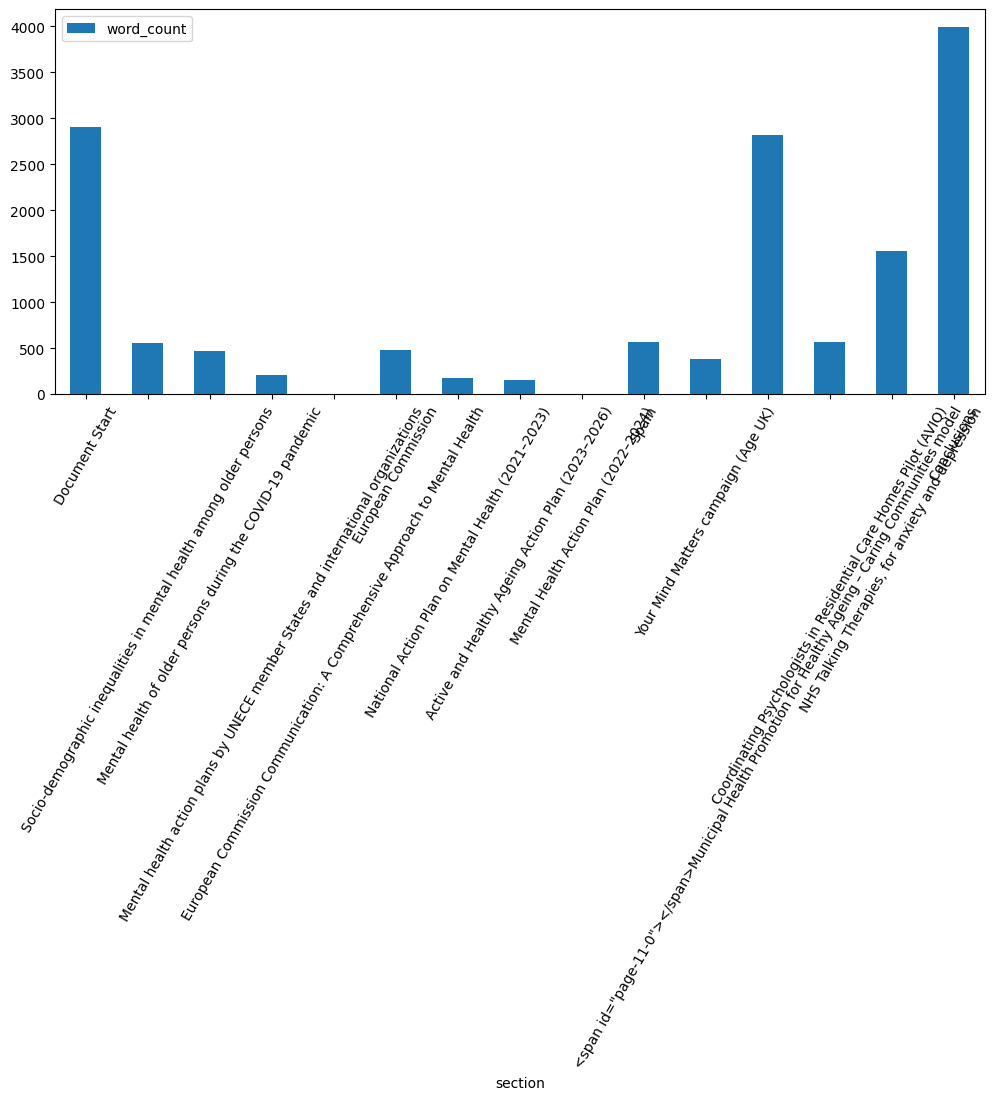

In [33]:
# Section Length Analysis
sections = []

current_title = "Document Start"
current_content = []

for line in markdown_text.splitlines():

    if line.startswith("## "):

        sections.append(
            {
                "section": current_title,
                "content": "\n".join(current_content),
            }
        )

        current_title = line.replace("## ", "")
        current_content = []

    else:
        current_content.append(line)

sections.append(
    {
        "section": current_title,
        "content": "\n".join(current_content),
    }
)

section_df = pd.DataFrame(sections)

section_df["word_count"] = (
    section_df["content"]
    .str.findall(r"[A-Za-z]+")
    .str.len()
)

section_df.sort_values(
    "word_count",
    ascending=False,
)

section_df.plot(
    x="section",
    y="word_count",
    kind="bar",
    figsize=(12, 5),
)

plt.xticks(rotation=60)
plt.show()

            word  frequency
0         health        419
1         mental        361
2          older        310
3        persons        245
4           page        168
5          https        154
6           care        108
7            www         98
8          among         95
9       services         78
10    depression         70
11        social         67
12       support         65
13           pdf         61
14          span         60
15          life         47
16           age         47
17           org         47
18     disorders         46
19          also         46
20        ageing         44
21          well         42
22        policy         41
23     available         39
24         unece         37
25           int         37
26          risk         35
27        report         35
28  publications         35
29  psychosocial         30


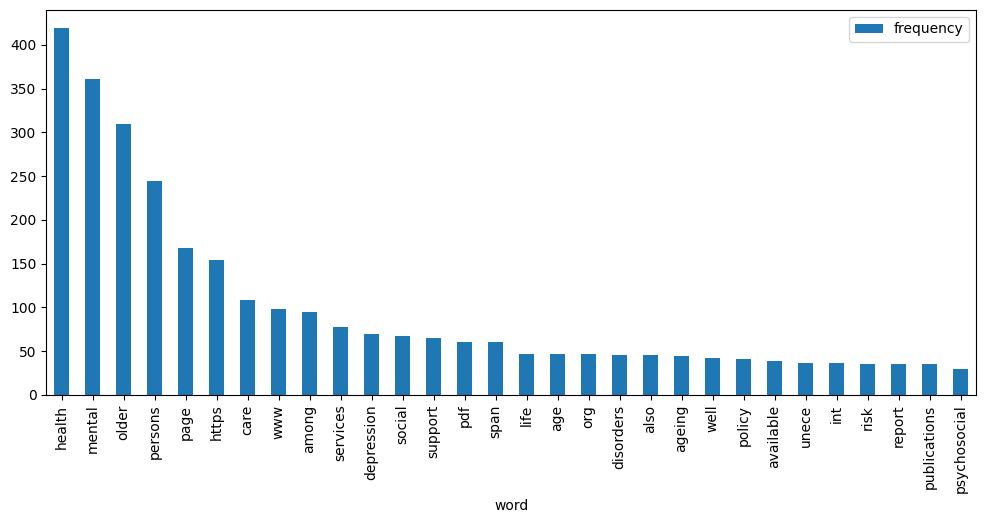

In [44]:
# Keyword Frequency Analysis
stop_words = set(
    stopwords.words("english")
)

words = [
    w
    for w in tokens
    if w not in stop_words
       and len(w) > 2
]

counter = Counter(words)

# Top 30 keys
keyword_df = pd.DataFrame(
    counter.most_common(30),
    columns=["word", "frequency"],
)

print(keyword_df)

# Visualize
keyword_df.plot(
    x="word",
    y="frequency",
    kind="bar",
    figsize=(12, 5),
)

plt.show()

In [45]:
# Bigram Analysis
bigrams = Counter(
    ngrams(words, 2)
)

bigram_df = pd.DataFrame(
    [
        (" ".join(bg), count)
        for bg, count
        in bigrams.most_common(20)
    ],
    columns=["bigram", "frequency"]
)

bigram_df

,bigram,frequency
0,mental health,295
1,older persons,215
2,https www,89
3,among older,68
4,health care,36
5,span page,33
6,page span,31
7,health older,31
8,mental disorders,29
9,health services,27


In [48]:
# Named Entity Analysis
nlp = spacy.load(
    "en_core_web_md"
)

doc = nlp(markdown_text)

entity_counter = Counter(
    (
        ent.text,
        ent.label_
    )
    for ent in doc.ents
)

entity_df = pd.DataFrame(
    [
        (text, label, count)
        for (text, label), count
        in entity_counter.most_common(50)
    ],
    columns=[
        "entity",
        "label",
        "frequency",
    ]
)

print(entity_df)

gpe_df = entity_df[
    entity_df["label"] == "GPE"
    ]

gpe_df.head(20)

                       entity     label  frequency
0                        ####     MONEY         33
1                       UNECE       ORG         19
2   World Health Organization       ORG         13
3                      Geneva       GPE         13
4                      Europe       LOC         12
5                        2022  CARDINAL         12
6                        2023  CARDINAL         12
7                        2020      DATE         11
8                 #### Mental     MONEY          7
9                          22  CARDINAL          6
10                       five  CARDINAL          6
11                       2018      DATE          6
12                    Austria       GPE          6
13                        NHS       ORG          6
14                          2  CARDINAL          5
15                         60      DATE          5
16          the United States       GPE          5
17                   European      NORP          5
18                    Türkiye  

,entity,label,frequency
3,Geneva,GPE,13
12,Austria,GPE,6
16,the United States,GPE,5
18,Türkiye,GPE,5
19,Slovakia,GPE,5
23,Belarus,GPE,4
24,Kazakhstan,GPE,4
26,the Republic of Moldova,GPE,4
27,the United Kingdom,GPE,4
31,London,GPE,4


In [50]:
# Readability Analysis
metrics = {
    "flesch_reading_ease":
        textstat.flesch_reading_ease(markdown_text),

    "flesch_kincaid_grade":
        textstat.flesch_kincaid_grade(markdown_text),

    "gunning_fog":
        textstat.gunning_fog(markdown_text),
}

print(pd.Series(metrics))

flesch_reading_ease     10.567134
flesch_kincaid_grade    16.336283
gunning_fog             17.496735
dtype: float64


In [73]:
# Chunking Simulation
def estimate_tokens(text):
    return len(text.split()) * 1.3


chunk_size = 1000

chunks = [
    markdown_text[i:i + chunk_size]
    for i in range(
        0,
        len(markdown_text),
        chunk_size
    )
]

chunk_df = pd.DataFrame(
    {
        "chunk_id":
            range(len(chunks)),
        "chars":
            [len(c) for c in chunks],
        "estimated_tokens":
            [
                estimate_tokens(c)
                for c in chunks
            ]
    }
)

chunk_df.describe()

,chunk_id,chars,estimated_tokens
count,115.000000,115.000000,115.000000
mean,57.000000,993.704348,151.704348
std,33.341666,67.513348,46.949330
min,0.000000,276.000000,2.600000
25%,28.500000,1000.000000,116.350000
50%,57.000000,1000.000000,172.900000
75%,85.500000,1000.000000,187.200000
max,114.000000,1000.000000,218.400000


In [74]:
# Heading-Aware Chunking
structured_chunks = []

for _, row in section_df.iterrows():
    structured_chunks.append(
        {
            "section":
                row["section"],
            "word_count":
                row["word_count"],
            "content":
                row["content"],
        }
    )

print(len(structured_chunks))

15


In [75]:
section_df[[
    "section",
    "word_count"
]].sort_values(
    "word_count",
    ascending=False
)

,section,word_count
14,Conclusions,3989
0,Document Start,2911
11,"<span id=""page-11-0""></span>Municipal Health P...",2817
13,"NHS Talking Therapies, for anxiety and depression",1556
9,Spain,565
12,Coordinating Psychologists in Residential Care...,565
1,Socio-demographic inequalities in mental healt...,554
5,European Commission,484
2,Mental health of older persons during the COVI...,465
10,Your Mind Matters campaign (Age UK),382


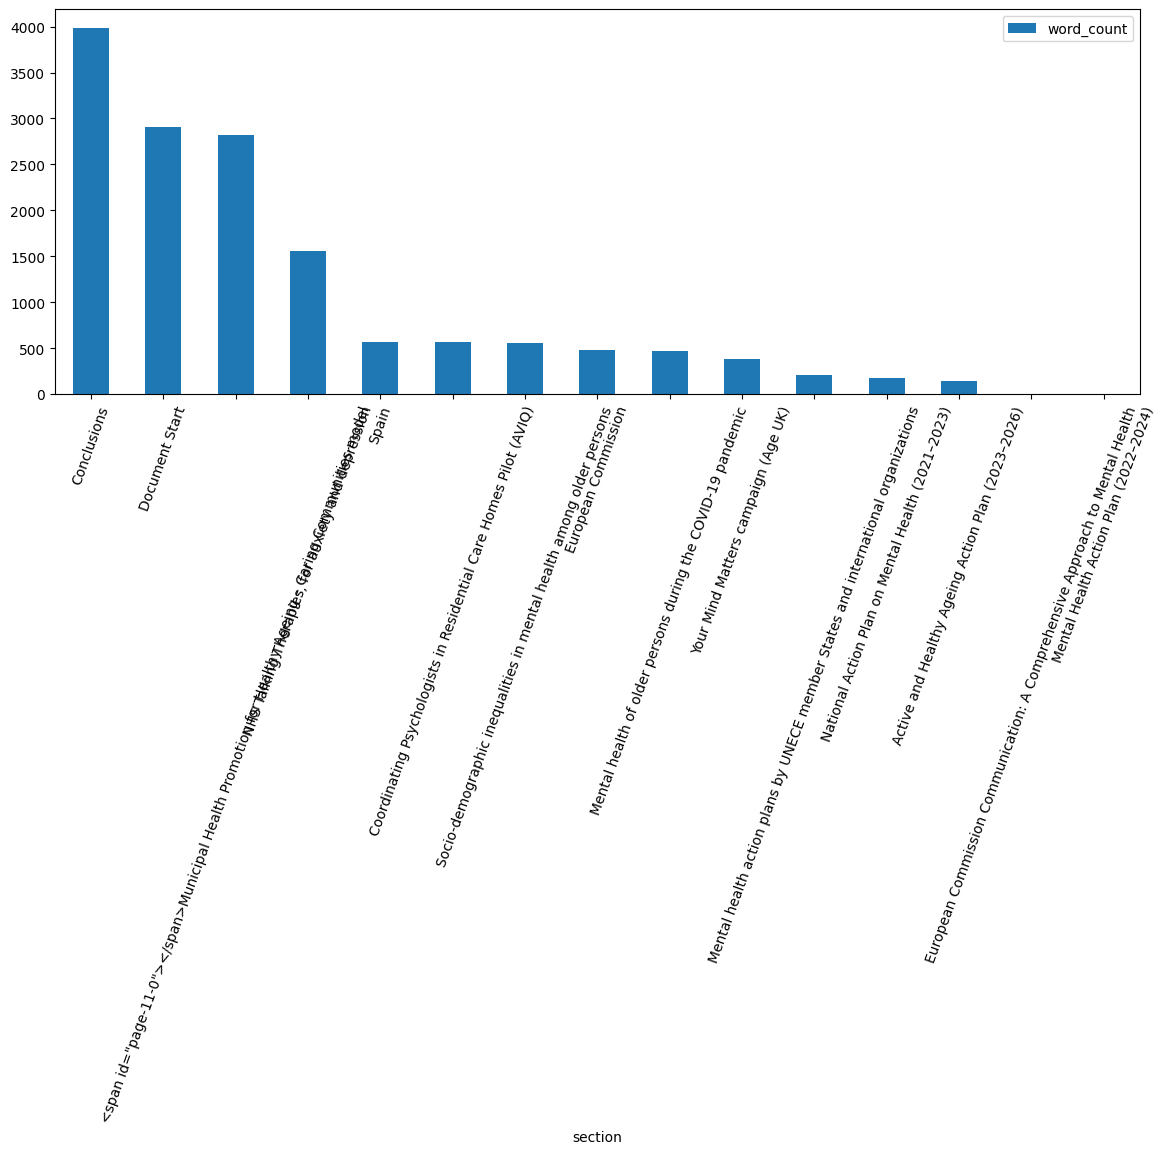

In [76]:
# Section Length Distribution
section_df.sort_values(
    "word_count",
    ascending=False
).plot(
    x="section",
    y="word_count",
    kind="bar",
    figsize=(14, 5),
)

plt.xticks(rotation=70)
plt.show()

In [77]:
# Section Keyword Analysis
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
)

X = vectorizer.fit_transform(
    section_df["content"]
)

feature_names = vectorizer.get_feature_names_out()

for idx, row in section_df.iterrows():

    scores = X[idx].toarray()[0]

    top_idx = scores.argsort()[-10:][::-1]

    print("\n")
    print(row["section"])

    for i in top_idx:
        print(feature_names[i])



Document Start
mental
health
older
persons
21
life
page
risk
depression
social


Socio-demographic inequalities in mental health among older persons
men
suicide
older
attainment
women
depression
gender
likely
educational
higher


Mental health of older persons during the COVID-19 pandemic
pandemic
older
persons
health
mental
worsening
connections
page
31
social


Mental health action plans by UNECE member States and international organizations
352549
health
9789289057813
bitstream
iris
int
10665
eng
mental
framework


European Commission Communication: A Comprehensive Approach to Mental Health
životného
doi
douglas
double
doorslaer
domicile
domains
domain
documents
diverse


European Commission
ec
eu
europa
health
mental
filename
document
cef45b6d
9d62
demo


National Action Plan on Mental Health (2021–2023)
hsgm
saglik
depo
tr
yayinlarimiz
eylem_planlari
ulusal_ruh_sagligi_eylem_plani_2021
gov
strengthen
pdf


Active and Healthy Ageing Action Plan (2023–2026)
pt
mental
sns
noticias


In [78]:
# Similarity Between Sections
sim = cosine_similarity(X)

sim_df = pd.DataFrame(
    sim,
    index=section_df["section"],
    columns=section_df["section"],
)

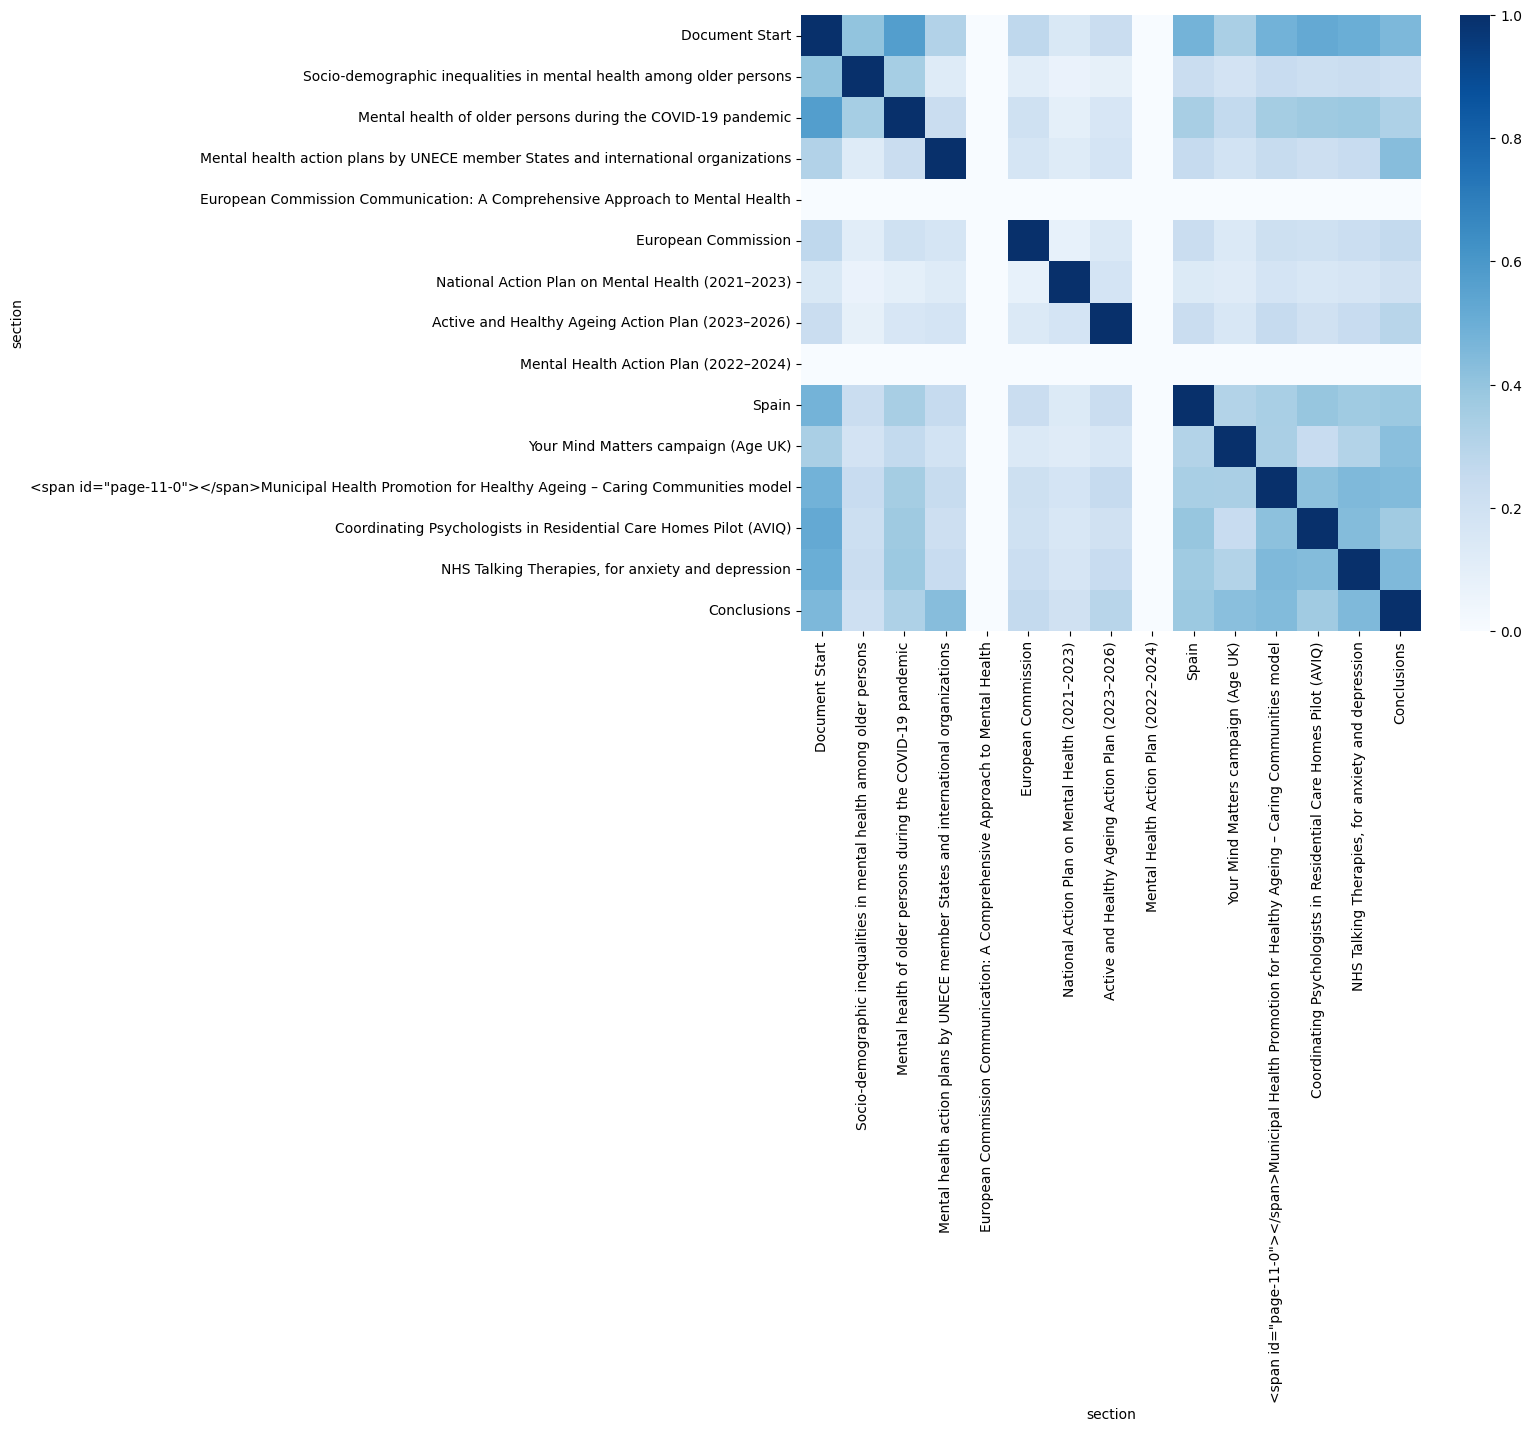

In [79]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    sim_df,
    cmap="Blues"
)

plt.show()

In [80]:
# Chunkability Score
section_df["needs_split"] = (
    section_df["word_count"] > 1500
)
section_df[[
    "section",
    "word_count",
    "needs_split"
]]

,section,word_count,needs_split
0,Document Start,2911,True
1,Socio-demographic inequalities in mental healt...,554,False
2,Mental health of older persons during the COVI...,465,False
3,Mental health action plans by UNECE member Sta...,213,False
4,European Commission Communication: A Comprehen...,0,False
5,European Commission,484,False
6,National Action Plan on Mental Health (2021–2023),174,False
7,Active and Healthy Ageing Action Plan (2023–2026),149,False
8,Mental Health Action Plan (2022–2024),0,False
9,Spain,565,False


In [53]:
print("Document words:", len(tokens))
print("Vocabulary size:", len(set(tokens)))
print("Sections:", len(section_df))
print("Top keyword:", keyword_df.iloc[0]["word"])
print("Chunks:", len(chunks))

Document words: 14916
Vocabulary size: 2196
Sections: 15
Top keyword: health
Chunks: 115


# Conclusion

* PDF → Markdown conversion using Marker
* Document structure analysis (headings and section hierarchy)
* Basic text statistics (word count, vocabulary size, lexical diversity)
* Section-level analysis (section count, section length distribution)
* Keyword and bigram frequency analysis
* Named Entity Recognition (countries, organizations, etc.)
* Readability analysis
* Chunking experiments for RAG

I compared two chunking strategies:

1. Fixed-size chunking \(1000 characters\), which produced 115 chunks with an average size of around 150–200 tokens.
2. Heading-aware chunking based on the document structure identified by Marker, which produced 15 semantic sections.

The results suggest that heading-aware chunking is much more suitable for UNECE policy documents because it preserves the logical structure of the content. The next step will be to analyze token distributions within sections and determine which sections should be further split before indexing into a vector database.

I have uploaded the notebook and can share the findings in more detail if anyone is interested.
